## Decission Tree

In [ ]:
## can be used for both classification amd regression 

In [3]:
import pandas as pd

In [22]:
df=pd.read_csv("Breastcancer.csv", index_col=0)
df

,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
Code,,,,,,,,,,
61634,5,4,3,1,2,2,2,3,1,Benign
63375,9,1,2,6,4,10,7,7,2,Malignant
76389,10,4,7,2,2,8,6,1,1,Malignant
95719,6,10,10,10,8,10,7,10,7,Malignant
128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...
1369821,10,10,10,10,5,10,10,10,7,Malignant
1371026,5,10,10,10,4,10,5,6,3,Malignant
1371920,5,1,1,1,2,1,3,2,1,Benign


In [7]:
df.isnull().sum()

Code             0
Clump            0
UniCell_Size     0
Uni_CellShape    0
MargAdh          0
SEpith           0
BareN            0
BChromatin       0
NoemN            0
Mitoses          0
Class            0
dtype: int64

In [24]:
x=df.drop("Class", axis=1)
y=df["Class"]

x

,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses
Code,,,,,,,,,
61634,5,4,3,1,2,2,2,3,1
63375,9,1,2,6,4,10,7,7,2
76389,10,4,7,2,2,8,6,1,1
95719,6,10,10,10,8,10,7,10,7
128059,1,1,1,1,2,5,5,1,1
...,...,...,...,...,...,...,...,...,...
1369821,10,10,10,10,5,10,10,10,7
1371026,5,10,10,10,4,10,5,6,3
1371920,5,1,1,1,2,1,3,2,1


In [13]:
x.isnull().sum()

Code             0
Clump            0
UniCell_Size     0
Uni_CellShape    0
MargAdh          0
SEpith           0
BareN            0
BChromatin       0
NoemN            0
Mitoses          0
dtype: int64

In [14]:
y

0         Benign
1      Malignant
2      Malignant
3      Malignant
4         Benign
         ...    
694    Malignant
695    Malignant
696       Benign
697       Benign
698       Benign
Name: Class, Length: 699, dtype: object

In [15]:
y.isnull().sum()

np.int64(0)

In [16]:
y.isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
694    False
695    False
696    False
697    False
698    False
Name: Class, Length: 699, dtype: bool

In [17]:
x.isnull()

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
694,False,False,False,False,False,False,False,False,False,False
695,False,False,False,False,False,False,False,False,False,False
696,False,False,False,False,False,False,False,False,False,False
697,False,False,False,False,False,False,False,False,False,False


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=24,test_size=0.3)

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
dtc=DecisionTreeClassifier(random_state=24,max_depth=3)
dtc.fit(x_train,y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

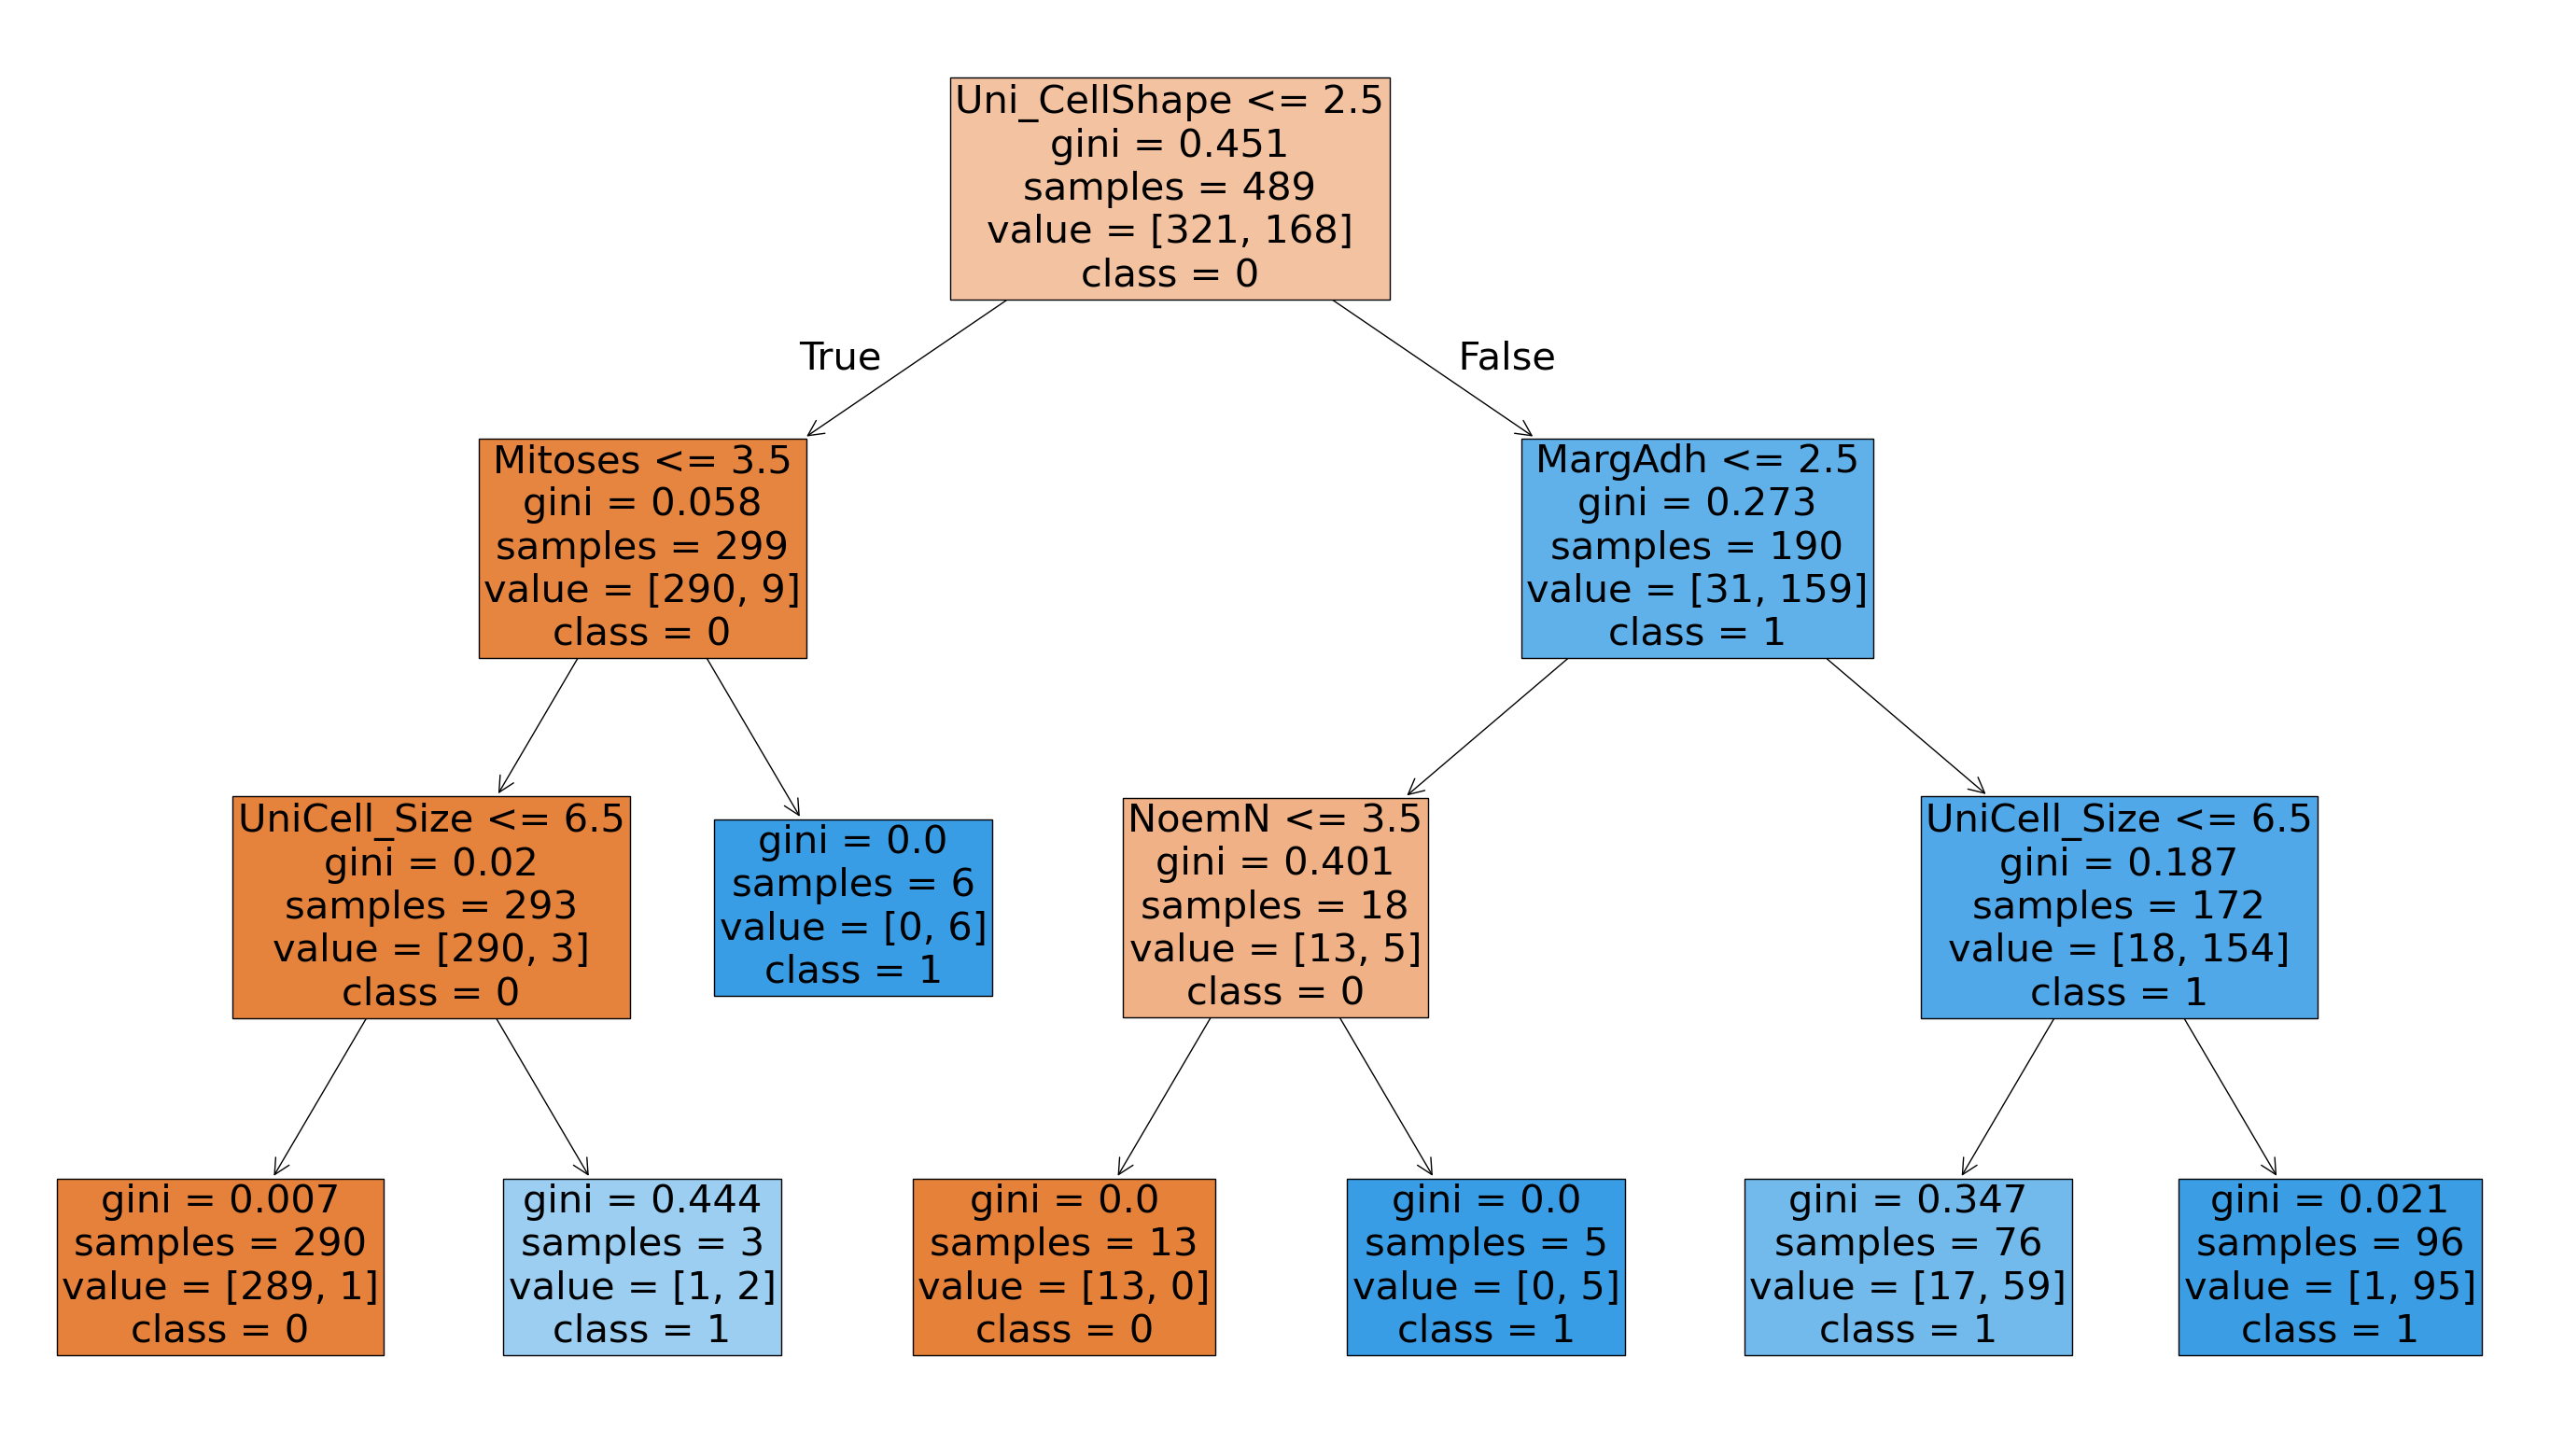

In [45]:
plt.figure(figsize=(35,20))
plot_tree(dtc,feature_names=list(x.columns),class_names=['0','1'],filled=True,fontsize=30)
plt.show()         

In [50]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [51]:
y_pred=dtc.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.9476190476190476


In [52]:
y_pred_prob=dtc.predict_proba(x_test)[:,1]
print(roc_auc_score(y_test,y_pred_prob))

0.94990500949905
